<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 8 (Decision Tree Classification)</b></center>    
<pre>    

# import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Import cardio_cleaned.csv dataset

In [2]:
df = pd.read_csv('cardio_cleaned.csv')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,0,18393,1,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,1,20228,0,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,2,18857,0,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
3,3,17623,1,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,4,17474,0,156,56.0,100,60,1,1,0,0,0,0,47,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68631,99993,19240,1,168,76.0,120,80,1,1,1,0,1,0,52,26.927438
68632,99995,22601,0,158,126.0,140,90,2,2,0,0,1,1,61,50.472681
68633,99996,19066,1,183,105.0,180,90,3,1,0,1,0,1,52,31.353579
68634,99998,22431,0,163,72.0,135,80,1,2,0,0,0,1,61,27.099251


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68636 entries, 0 to 68635
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           68636 non-null  int64  
 1   age          68636 non-null  int64  
 2   gender       68636 non-null  int64  
 3   height       68636 non-null  int64  
 4   weight       68636 non-null  float64
 5   ap_hi        68636 non-null  int64  
 6   ap_lo        68636 non-null  int64  
 7   cholesterol  68636 non-null  int64  
 8   gluc         68636 non-null  int64  
 9   smoke        68636 non-null  int64  
 10  alco         68636 non-null  int64  
 11  active       68636 non-null  int64  
 12  cardio       68636 non-null  int64  
 13  age_years    68636 non-null  int64  
 14  bmi          68636 non-null  float64
dtypes: float64(2), int64(13)
memory usage: 7.9 MB


# Check the distribution of the target

In [4]:
print(df['cardio'].value_counts())

cardio
0    34677
1    33959
Name: count, dtype: int64


# Check for missing values

In [5]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
bmi            0
dtype: int64

# Visualize Distributions

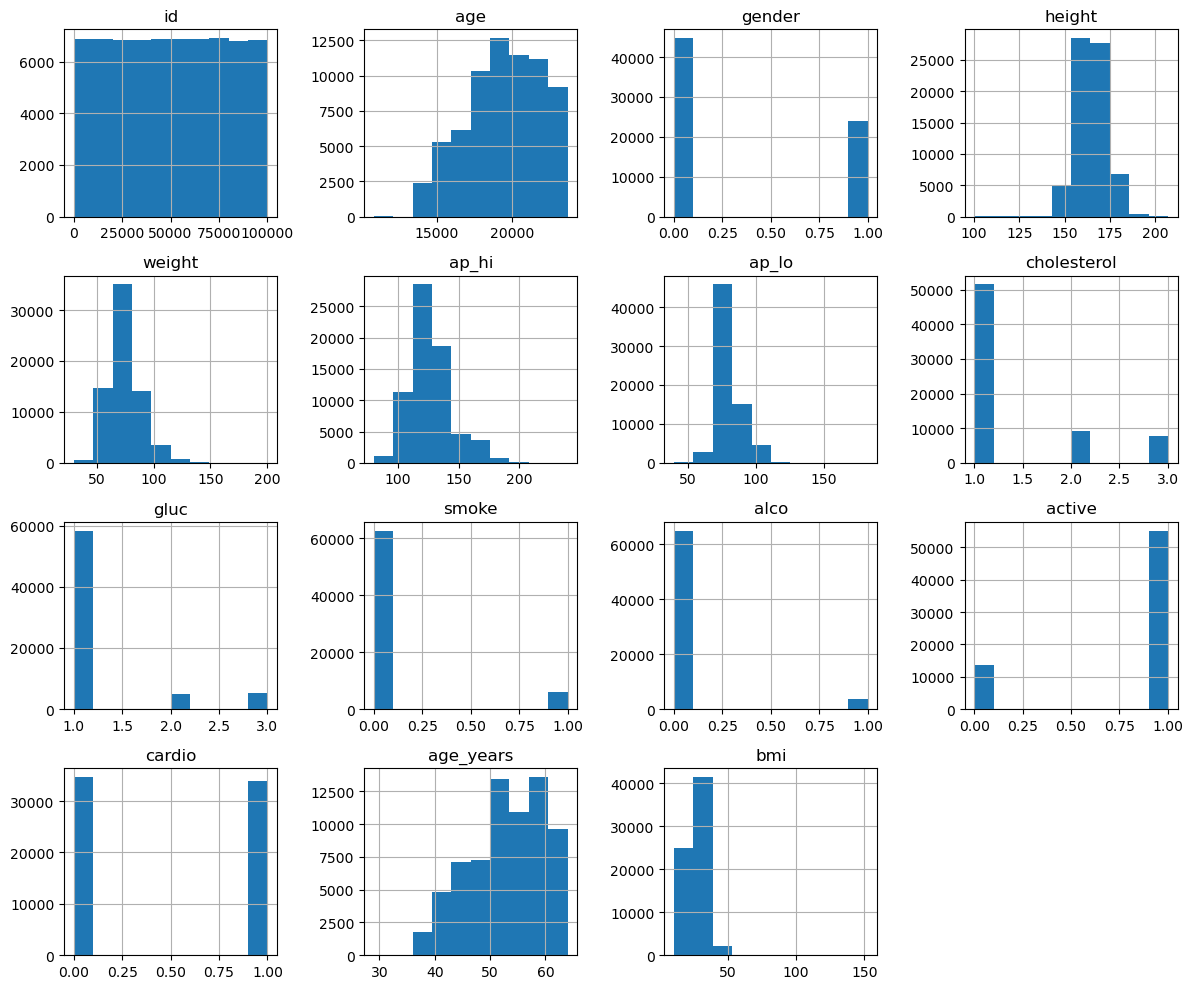

In [6]:
df.hist(figsize=(12,10))

plt.tight_layout()

plt.show()

# Convert Targer data into interger code

In [7]:
df['cardio'].unique()

array([0, 1])

In [8]:
le = LabelEncoder()
df['cardio'] = le.fit_transform(df['cardio'])

In [9]:
df['cardio']

0        0
1        1
2        1
3        1
4        0
        ..
68631    0
68632    1
68633    1
68634    1
68635    0
Name: cardio, Length: 68636, dtype: int64

# Divide the data into input and output

In [10]:
# Axis = 1 means drop column, axis = 0 means drop row
x = df.drop(['cardio', 'id'], axis=1) 
y = df['cardio']

# shape gives the number of rows and columns in the dataset
print(x.shape)
# y.shape gives the number of rows and columns in the dataset
print(y.shape) 

(68636, 13)
(68636,)


# Splitting the dataset into the Training set and Test set

In [11]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
X_train.shape

(54908, 13)

In [13]:
X_test.shape

(13728, 13)

# Create Model

In [14]:
from sklearn.tree import DecisionTreeClassifier

In [15]:
model = DecisionTreeClassifier()

# Fitting DecisionTreeClassifier   on dataset

In [16]:
for depth in range(1,11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(f"Depth: {depth}, TrainingAccuracy: {model.score(X_train,y_train)},"
          f"TestingAccuracy: {model.score(X_test,y_test)}")

Depth: 1, TrainingAccuracy: 0.7138668317913601,TestingAccuracy: 0.7099358974358975


Depth: 2, TrainingAccuracy: 0.7138668317913601,TestingAccuracy: 0.7099358974358975


Depth: 3, TrainingAccuracy: 0.7254680556567349,TestingAccuracy: 0.7226835664335665


Depth: 4, TrainingAccuracy: 0.728782691046842,TestingAccuracy: 0.727782634032634


Depth: 5, TrainingAccuracy: 0.7327165440372988,TestingAccuracy: 0.7305506993006993


Depth: 6, TrainingAccuracy: 0.734592409120711,TestingAccuracy: 0.7293123543123543


Depth: 7, TrainingAccuracy: 0.7363954250746704,TestingAccuracy: 0.7304050116550117


Depth: 8, TrainingAccuracy: 0.7413309535951046,TestingAccuracy: 0.7267628205128205


Depth: 9, TrainingAccuracy: 0.7465032417862607,TestingAccuracy: 0.7278554778554779


Depth: 10, TrainingAccuracy: 0.7520762001894077,TestingAccuracy: 0.7296037296037297


# Display Decision Tree

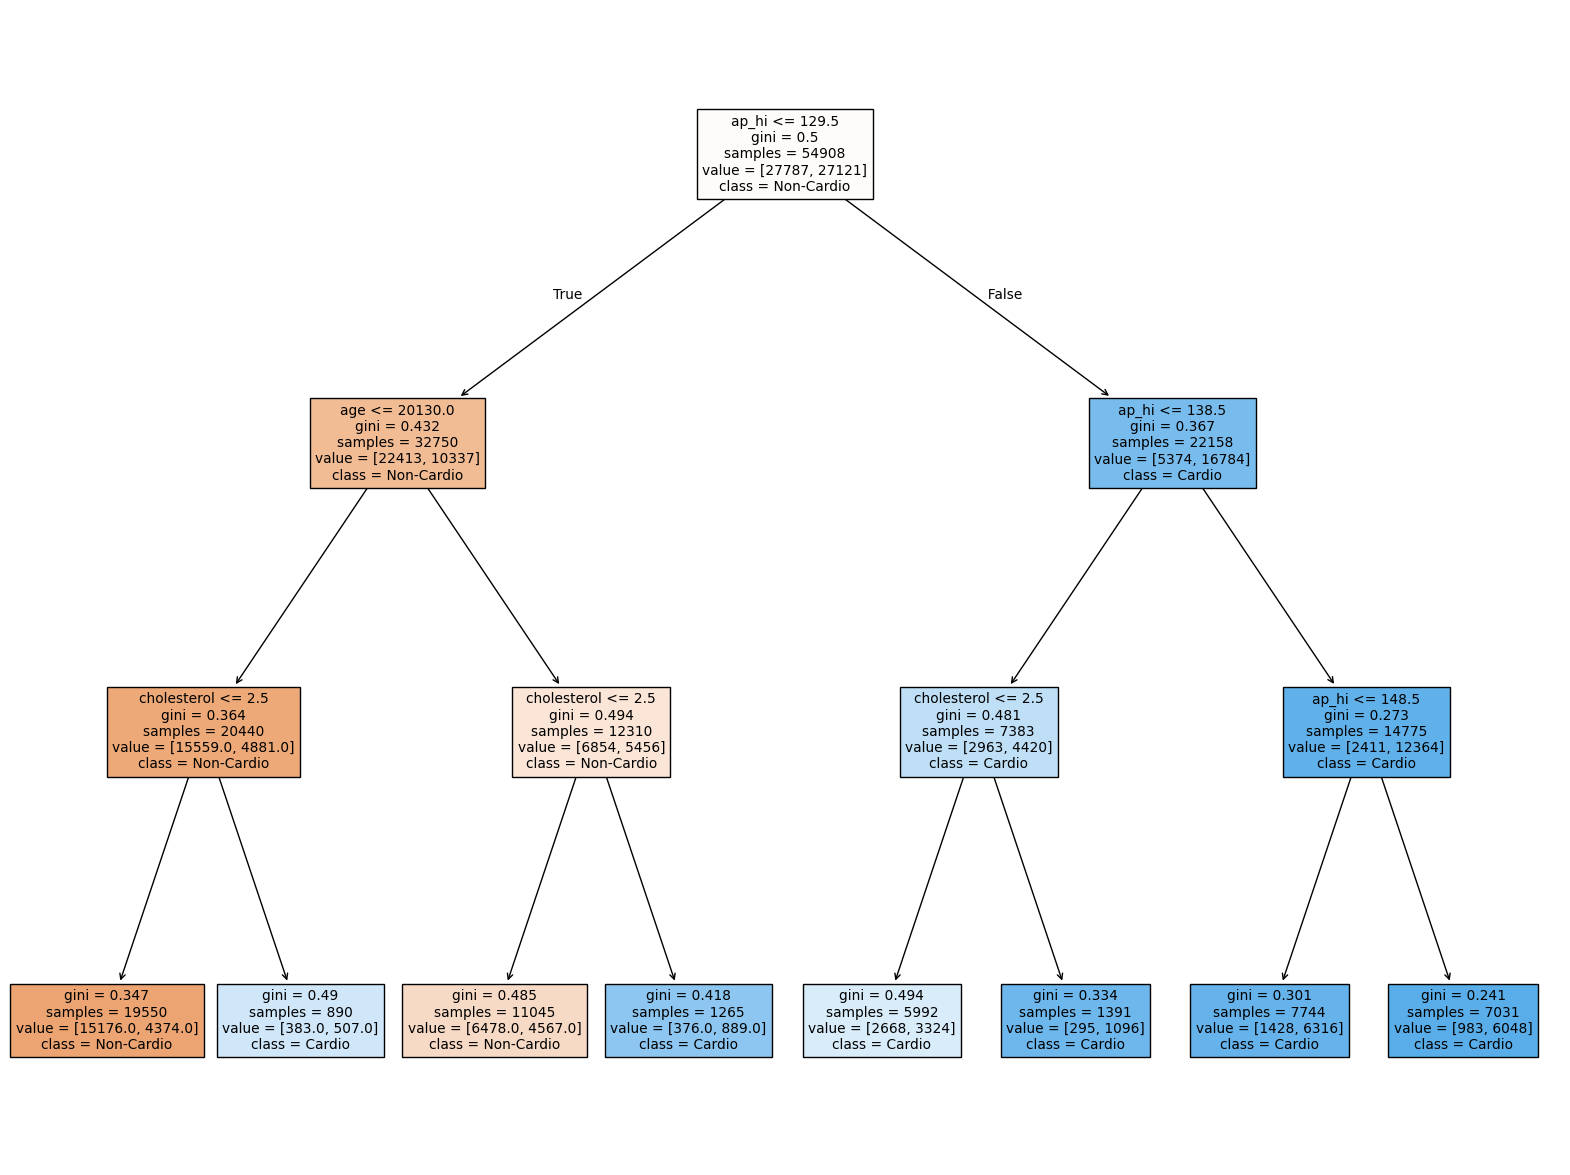

In [17]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

plt.figure(figsize=(20,15))

plot_tree(model,filled=True,feature_names=x.columns,class_names=['Non-Cardio','Cardio'])

plt.show()

# Predict the x_test 

In [18]:
y_pred = model.predict(X_test)
print(y_pred)

[0 1 1 ... 1 0 0]


# Display Training Accuracy

In [19]:
TrainingAccuracy = model.score(X_train,y_train)
TrainingAccuracy

0.7254680556567349

# Display Test Accuracy

In [20]:
testAccuracy = model.score(X_test,y_test)

testAccuracy

0.7226835664335665